Nick and Aidan

In [1]:
#https://www.kaggle.com/datasets/rkiattisak/salaly-prediction-for-beginer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
#Importing all necessary libraries for this linear regression model
#The only library we didn't use the Polynomial Features as we wanted to make as accurate linear graph, also inluding what was possible with the data we had.

In [2]:
#Importing our dataset into Google Colab and displaying the table
from google.colab import files
uploaded=files.upload()
df=pd.read_csv('Salary Data.csv')
df.head()

Saving Salary Data.csv to Salary Data.csv


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [3]:
df.isnull().sum() #Checking for any null values in the dataset

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [4]:
#Since this regression requires one dependent and one independent value, we decided to keep the years of experience and base that off their salary
#We dropped all the unqualified columns
df.drop('Age', axis=1, inplace=True)
df.drop('Gender', axis=1, inplace=True)
df.drop('Education Level', axis=1, inplace=True)
df.drop('Job Title', axis=1, inplace=True)

In [5]:
#We dropped all null values from the columns we decided to keep
df= df.dropna(subset=['Years of Experience'])
df=df.dropna(subset=['Salary'])
df

,Years of Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0
...,...,...
370,8.0,85000.0
371,19.0,170000.0
372,2.0,40000.0
373,7.0,90000.0


In [6]:
df.isnull().sum() # double checking all null values were dropped

,0
Years of Experience,0
Salary,0


In [7]:
#We changed the format from floats to integers
#Eventually we want to enter integers when predicting employees salary based off of years of experience
columns_to_convert=['Years of Experience', 'Salary']
df[columns_to_convert] = df[columns_to_convert].astype(int)
df

,Years of Experience,Salary
0,5,90000
1,3,65000
2,15,150000
3,7,60000
4,20,200000
...,...,...
370,8,85000
371,19,170000
372,2,40000
373,7,90000


In [8]:
#setting the x and y variables
#X is set toward the years of experience
#Y is set towards the salary
x=df[['Years of Experience']]
y =df['Salary']

In [9]:
#Splitting the columns/data into different training and testing sets
#We fixed the best best test size and random state to ge the best mse and r2 score
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model=LinearRegression() #This code starts and trains a linear regression model
model.fit(x_train, y_train)

y_pred = model.predict(x_test) #This starts the predictions with tests sets we have split

mse = mean_squared_error(y_test, y_pred) #This evaluates the mse and r2 of the model
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}") #prints out the mse and r2 score
print(f"R-Squared: {r2}")

Mean Squared Error: 242321860.95952058
R-Squared: 0.8989307400123604


In [10]:
def get_prediction(): #We will starting having the user enter a number of years to predict a salary based off of experience
    while True: #This only includes years of experience since we are only using one indepedent variable
        try:# the if statements ensure the users are not inputting a negative number
            YearsofExperience = int(input("Enter the years of experience:"))
            if YearsofExperience < 0:
                print("Please enter a non negative number")
                #This created the array for the years of experience or the variable X
            input_data = np.array([[YearsofExperience]])
            #This makes the overall prediction from your choices
            predicted_price = model.predict(input_data)[0]
            #The is prints out the final predicted salary
            print(f"Predicted Salary: ${predicted_price:.2f}")
            break
            #The rest of this code restates if the user inputted a variable correctly
            #It will tell the user to retry and inputt a correct variable
        except ValueError:
            print("Invalid input. Please enter a valid integer for X.")
        except Exception as e:
            print(f"An error occured: {e}")
            print("Please reenter the correct values.")
            break
while True: #After you finish, it will give you an option to try another prediction
      get_prediction()
      another_prediction = input("Do you want to predict another price? (Yes/No)")
      if another_prediction.lower() !='yes':
        break

Enter the years of experience:5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Salary: $65879.55
Do you want to predict another price? (Yes/No)yes
Enter the years of experience:12


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Salary: $113471.35
Do you want to predict another price? (Yes/No)no


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


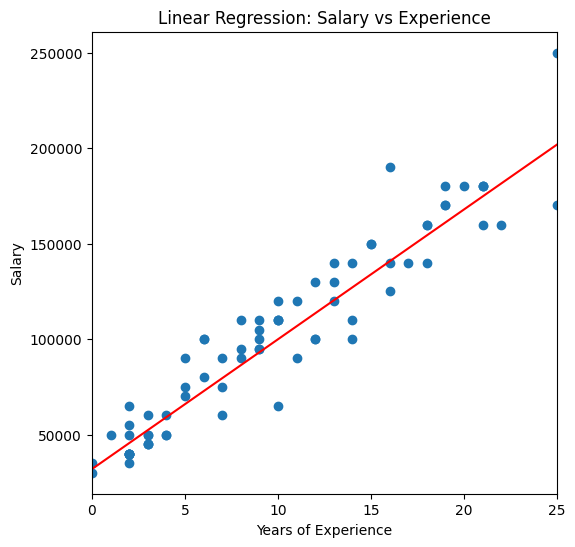

In [11]:
#Creating the layout of the scatterplot from testing sets we created
plt.figure(figsize=(6,6))
plt.scatter(x_test, y_test)

import numpy as np
#This creates the range for the X variable
#Starting at the lowest possible value that starts at the years of experience and vise versa for the max row
#Spacing the numbers out evenly.
x_line = np.linspace(df['Years of Experience'].min(),
                     df['Years of Experience'].max(),
                     100).reshape(-1,1)

y_line = model.predict(x_line) #Passes all experience values into the graph
#Creates the specifics: the line, the x and y label, and the title
plt.plot(x_line, y_line, color='red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression: Salary vs Experience")
#Forces the axis to stay within a realistic value regarding years of experience
plt.xlim(df['Years of Experience'].min(),
         df['Years of Experience'].max())

plt.show()

In [ ]:
#The only feature engineering we decided to use was clearing the null values and drop columns because that was all that was needed in order for the regression algorithm to work correctly.
#We did not use label encoder because everything was in a number format already.

 My partner and I decided to display a chosen dataset to show a linear regression model. We decided to use this salary dataset that contained variables like age, gender, job title, years of experience, and education level. We want to use only one of these values to determine these employees salary which is years of experience. We thought years of experience was stronger regarding predictions of salary. We used the actual years of experience with their assigned salary compared it with the predicted values. We wanted to users to decide on the years of experience themselves and see what kind of salary they get. We also created a model where the red line shows the actual years and salary given from the data. The blue dots represent the preedicted salary from the years of experience. This specific algorithm required only one variable to rely on one other variable that would determine the salary. If we were to use multiple variables like age and gender, then these dots would be placed differently and most likely way more spread out. The dots currently almost line up perfectly with the red line because of the dataset we chose and only one variable that we decided to use.